# Detectie Deepfake folosind Transfer Learning

In [1]:
%pip install opencv-python
%pip install matplotlib
%pip install seaborn
%pip install torchvision
%pip install mediapipe
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import platform
import sys

print(f"Arhitectură: {platform.architecture()[0]}")
print(f"Versiune Python: {sys.version}")

Arhitectură: 64bit
Versiune Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


## 1. Importuri

In [33]:
# am pus toate importurile intr-un singur loc ca sa nu le caut prin tot fisierul
# le-am grupat dupa rol ca sa fie mai usor de citit
# [[[[[[ un import = o librarie. 'as' e un alias - scurtatura ca sa nu scrii numele intreg de fiecare data ]]]]]]

# sistem de fisiere si download
import os
import urllib.request

# procesare imagini si grafice
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [[[[[[  PyTorch e framework-ul principal pentru retele neuronale in Python
#         torch.nn contine layere, torch.optim contine algoritmii de optimizare
#         torchvision are modele gata construite + utilitare pentru imagini ]]]]]]
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from PIL import Image
from torch.utils.data import WeightedRandomSampler

# detectie fata in timp real
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# metrici de evaluare a modelului
from sklearn.metrics import confusion_matrix, classification_report

# verificam de la inceput pe ce rulam - GPU sau CPU
# [[[[[[ torch.cuda.is_available() verifica daca exista o placa video NVIDIA compatibila
#        daca nu, antrenamentul ruleaza pe CPU - mai lent dar functional ]]]]]]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ruleaza pe: {device}")

Ruleaza pe: cuda


## 2. Extragere Cadre din Video

### 2a. Detectie si Decupare Fata

In [6]:
# modelul de detectie BlazeFace il descarcam automat daca nu e deja pe disc
# [[[[[[ BlazeFace e un model mic (~1MB) de la Google, optimizat sa mearga rapid pe orice device
#        tflite = TensorFlow Lite, format comprimat pentru inferenta, nu pentru antrenament ]]]]]]
TFLITE_MODEL = 'blaze_face_short_range.tflite'

if not os.path.exists(TFLITE_MODEL):
    url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
    urllib.request.urlretrieve(url, TFLITE_MODEL)
    print("model descarcat")

# initializam detectorul o singura data aici si il refolosim peste tot
# mai eficient decat sa il reinitializam la fiecare frame
# [[[[[[ MediaPipe foloseste un sistem de 'options' pentru configurare
#        min_detection_confidence=0.5 = ignoram detectii cu siguranta sub 50% ]]]]]]
_base_opts = python.BaseOptions(model_asset_path=TFLITE_MODEL)
_det_opts  = vision.FaceDetectorOptions(base_options=_base_opts, min_detection_confidence=0.5)
face_detector = vision.FaceDetector.create_from_options(_det_opts)


def crop_face(frame_bgr):
    # OpenCV citeste BGR, MediaPipe vrea RGB - trebuie convertit inainte
    # [[[[[[ BGR = Blue-Green-Red, RGB = Red-Green-Blue - aceeasi culori, ordine diferita de canale ]]]]]]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_img    = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    results   = face_detector.detect(mp_img)

    # daca nu s-a detectat nicio fata sarim peste frame-ul asta
    if not results.detections:
        return None

    # in deepfakes e de obicei o singura fata, luam prima detectie
    # [[[[[[ bounding box = dreptunghiul care inconjoara fata detectata
    #        origin_x/y = coltul stanga-sus, width/height = dimensiunile ]]]]]]
    bbox = results.detections[0].bounding_box
    h, w = frame_rgb.shape[:2]
    bx, by, bw, bh = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height

    # adaugam margini generoase sa nu taiem parul, urechile sau barbia
    # dupa mai multe teste, 60% sus si 40% lateral dau cel mai bun crop
    # [[[[[[ max(0, ...) si min(w, ...) sunt safety clamps
    #        ne asiguram ca nu iesim din limitele imaginii originale ]]]]]]
    x1 = max(0, bx - int(bw * 0.4))
    y1 = max(0, by - int(bh * 0.6))
    x2 = min(w, bx + bw + int(bw * 0.4))
    y2 = min(h, by + bh + int(bh * 0.3))

    cropped = frame_rgb[y1:y2, x1:x2]

    # verificam sa nu avem un crop gol din cauza coordonatelor invalide
    if cropped.size == 0:
        return None

    # redimensionam la 224x224 - dimensiunea de intrare a EfficientNet
    # [[[[[[ INTER_LINEAR = interpolare bilineara, echilibru bun intre viteza si calitate ]]]]]]
    return cv2.resize(cropped, (224, 224), interpolation=cv2.INTER_LINEAR)

### 2b. Procesare Videoclipuri -> Imagini

In [7]:
def video_to_frames(src_dir, dst_dir, fps_target=3):
    # cream folderul de output daca nu exista deja
    os.makedirs(dst_dir, exist_ok=True)

    # construim lista de videoclipuri din directorul sursa
    # [[[[[[ list comprehension: construim o lista din mers, mai compact decat un for clasic
    #        f.name[:-4] sterge ultimele 4 caractere (.mp4) din numele fisierului ]]]]]]
    videos = [
        (f.name[:-4], os.path.abspath(f))
        for f in os.scandir(src_dir)
        if f.name.lower().endswith('.mp4')
    ]

    for vid_name, vid_path in videos:
        cap      = cv2.VideoCapture(vid_path)
        orig_fps = cap.get(cv2.CAP_PROP_FPS)

        # calculam la cate cadre citite sa salvam unul
        # ex: video de 30fps, vrem 3fps => salvam 1 cadru din 10
        # [[[[[[ max(1, ...) evita impartirea la zero daca fps_target > orig_fps ]]]]]]
        step = max(1, round(orig_fps / fps_target))

        frame_idx = 0
        saved     = 0

        while True:
            ok, frame = cap.read()
            # [[[[[[ cap.read() returneaza (True, frame) daca a citit cu succes
            #        la sfarsitul fisierului returneaza (False, None) ]]]]]]
            if not ok:
                break

            # procesam doar cadrele la intervalul calculat, restul le sarim
            if frame_idx % step == 0:
                face = crop_face(frame)
                # salvam doar daca fata a fost detectata cu succes
                if face is not None:
                    # [[[[[[ :04d = formatare cu zerouri in fata pana la 4 cifre
                    #        ex: saved=5 -> '0005', util pentru sortare alfabetica corecta ]]]]]]
                    fname = f"{vid_name}_{saved:04d}.jpg"
                    # reconvertim la BGR ca OpenCV sa salveze culorile corect
                    cv2.imwrite(os.path.join(dst_dir, fname), cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                    saved += 1

            frame_idx += 1

        cap.release()
        print(f"{vid_name}: {saved} cadre salvate")


# atentie: ordinea folderelor real/fake pare inversata - asa era organizat dataset-ul original
video_to_frames("dataset_video/fake/manipulated_sequences/DeepFakeDetection/c23/videos", "dataset_image/fake")
video_to_frames("dataset_video/fake/manipulated_sequences/Face2Face/c23/videos", "dataset_image/fake")


video_to_frames("dataset_video/real/original_sequences/actors/c23/videos", "dataset_image/real")
video_to_frames("dataset_video/real/original_sequences/youtube/c23/videos", "dataset_image/real")
print("gata extragerea")

01_02__exit_phone_room__YVGY8LOK: 15 cadre salvate
01_02__hugging_happy__YVGY8LOK: 70 cadre salvate
01_02__meeting_serious__YVGY8LOK: 0 cadre salvate
01_02__outside_talking_still_laughing__YVGY8LOK: 30 cadre salvate
01_02__secret_conversation__YVGY8LOK: 20 cadre salvate
01_02__talking_against_wall__YVGY8LOK: 106 cadre salvate
01_02__talking_angry_couch__YVGY8LOK: 182 cadre salvate
01_02__walking_and_outside_surprised__YVGY8LOK: 101 cadre salvate
01_02__walking_down_indoor_hall_disgust__YVGY8LOK: 97 cadre salvate
01_02__walking_outside_cafe_disgusted__YVGY8LOK: 18 cadre salvate
01_02__walk_down_hall_angry__YVGY8LOK: 2 cadre salvate
01_03__exit_phone_room__480LQD1C: 11 cadre salvate
01_03__hugging_happy__ISF9SP4G: 74 cadre salvate
01_03__kitchen_pan__JZUXXFRB: 56 cadre salvate
01_03__kitchen_still__JZUXXFRB: 67 cadre salvate
01_03__meeting_serious__JZUXXFRB: 0 cadre salvate
01_03__outside_talking_pan_laughing__ISF9SP4G: 17 cadre salvate
01_03__outside_talking_still_laughing__JZUXXFRB: 19

## 3. Construirea Modelului (Transfer Learning)

### 3a. Incarcare EfficientNet-B0 Preantrenat

In [39]:
# folosim EfficientNet-B0 preantrenat pe ImageNet ca punct de start
# [[[[[[ Transfer Learning = luam un model antrenat pe un dataset mare (ImageNet - 1.2 mil imagini)
#        si il adaptam pentru problema noastra specifica
#        avantaj: modelul 'stie' deja sa recunoasca forme, texturi, muchii ]]]]]]

# [[[[[[ EfficientNet-B0 e cel mai mic din familia EfficientNet (B0 -> B7)
#        am ales B0 ca merge si fara GPU si e suficient pentru clasificare binara ]]]]]]
weights = models.EfficientNet_B0_Weights.DEFAULT
model   = models.efficientnet_b0(weights=weights)
print("model incarcat")

model incarcat


In [9]:
# afisam arhitectura sa vedem ce modificam in pasul urmator
# [[[[[[ uitati-va la ultimul bloc 'classifier' - acela il vom inlocui ]]]]]]
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### 3b. Adaptare Classifier pentru Clasificare Binara

In [40]:
# inghetam toti parametrii modelului original - nu vrem sa stricam ce a invatat pe ImageNet
# antrenam doar capul nou pe care il atasam la final
# [[[[[[ requires_grad=False inseamna ca PyTorch nu va calcula gradientii pentru parametrul respectiv
#        fara gradient -> nu se updateaza la backpropagation -> parametrul ramane 'inghetat' ]]]]]]
for param in model.parameters():
    param.requires_grad = False

# citim numarul de intrari dinamic ca sa nu il scriem hardcodat
# [[[[[[ in_features la B0 e 1280 - iesirile feature extractor-ului ]]]]]]
in_features = model.classifier[1].in_features

# inlocuim capul original (1000 clase ImageNet) cu unul nou pentru 2 clase: real vs fake
# [[[[[[ nn.Linear = fully connected layer: y = xW + b
#        PyTorch seteaza automat requires_grad=True pe orice layer nou creat ]]]]]]
model.classifier[1] = nn.Linear(in_features, 2)

# mutam modelul pe device-ul disponibil
model = model.to(device)
print(f"model adaptat: {in_features} -> 2")

model adaptat: 1280 -> 2


## 4. Pregatire Dataset si DataLoaders

In [11]:
# definim transformarile pentru antrenament cu augmentare
# scopul augmentarii e sa prevenim overfitting-ul - modelul vede variante diferite ale aceluiasi chip
# [[[[[[ Data augmentation = generam variante modificate ale imaginilor la fiecare epoca
#        modelul nu vede exact aceeasi imagine de doua ori, asa invata sa generalizeze ]]]]]]
train_transforms = transforms.Compose([
    # flip orizontal - simuleaza fete orientate in directii diferite
    transforms.RandomHorizontalFlip(),
    # rotatie mica - simuleaza capete usor inclinate in video
    # [[[[[[ degrees=15 inseamna rotatie aleatoare intre -15 si +15 grade ]]]]]]
    transforms.RandomRotation(15),
    # variatie de luminozitate si contrast - camere si iluminat diferit
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # convertim imaginea PIL intr-un tensor PyTorch si scalat in [0, 1]
    # [[[[[[ ToTensor() converteste imaginea PIL/numpy (0-255) in tensor PyTorch (0.0-1.0) ]]]]]]
    transforms.ToTensor(),
    # normalizare cu valorile standard de pe ImageNet - necesar pentru modelul preantrenat
    # [[[[[[ modelul preantrenat a vazut date normalizate asa - daca nu normalizam la fel
    #        distributia inputului e diferita si performanta scade ]]]]]]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [27]:
# ImageFolder citeste automat clasele din numele subdirectoarelor
# structura: data_set/images/fake/*.jpg si data_set/images/real/*.jpg
# [[[[[[ ImageFolder asigneaza automat label 0 si 1 in ordine alfabetica
#        de aceea e important sa verificam class_to_idx sa stim care e 0 si care e 1 ]]]]]]
full_dataset = datasets.ImageFolder(root="dataset_image", transform=train_transforms)
print("clase detectate:", full_dataset.class_to_idx)

# impartim dataset-ul: 80% pentru antrenament, 20% pentru testare finala
# impartirea e aleatoare dar cele doua seturi nu se suprapun
# [[[[[[ random_split imparte dataset-ul aleator in doua subseturi disjuncte
#        important: modelul nu vede niciodata datele de test in timpul antrenamentului ]]]]]]
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_test  = n_total - n_train

train_set, test_set = random_split(full_dataset, [n_train, n_test])
print(f"train: {n_train} | test: {n_test}")

# avem ~3x mai multe imagini Fake decat Real, asa ca fara echilibrare
# modelul invata sa zica mereu 'Fake' si tot obtine 75% accuracy - nu e util
# solutia: WeightedRandomSampler - clasele rare sunt selectate mai des in batch-uri
# [[[[[[ ideea e simpla: daca clasa A are de 3x mai putine exemple decat B,
#        ii dam fiecarui exemplu din A o greutate de 3x mai mare
#        asa fiecare clasa apare aproximativ egal in fiecare batch ]]]]]]
labels_train = [full_dataset.targets[i] for i in train_set.indices]
class_counts  = np.bincount(labels_train)
print(f"distributie train -> Fake: {class_counts[0]} | Real: {class_counts[1]}")

# greutatea unui sample = 1 / numarul total de sample-uri din clasa lui
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in labels_train]
sample_weights = torch.DoubleTensor(sample_weights)

# [[[[[[ replacement=True = un sample poate fi ales de mai multe ori in aceeasi epoca
#        num_samples = dimensiunea unui 'epoch' artificial echilibrat ]]]]]]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# la train folosim sampler in loc de shuffle - nu pot fi folosite impreuna
# [[[[[[ batch_size=32 = procesam 32 imagini deodata
#        mai mare = mai rapid dar mai multa memorie; 32 e un compromis bun ]]]]]]
# [[[[[[ num_workers=0 = incarcarea pe thread-ul principal, evita probleme pe Windows ]]]]]]
train_loader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,   num_workers=0)

clase detectate: {'fake': 0, 'real': 1}
train: 258658 | test: 64665
distributie train -> Fake: 193591 | Real: 65067


## 5. Antrenare

In [41]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # outputs va avea forma [batch_size, 2]
        outputs = model(images) 
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        
        # torch.max returneaza (valori_maxime, indici_maximi)
        # Indicele (0 sau 1) reprezinta clasa prezisa
        _, predicted = torch.max(outputs, 1)
        
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    avg_loss = total_loss / total
    acc      = correct / total * 100
    print(f"Epoca {epoch+1}/{NUM_EPOCHS} | loss: {avg_loss:.4f} | acc: {acc:.2f}%")

print("antrenare terminata")

Epoca 1/1 | loss: 0.5515 | acc: 72.65%
antrenare terminata


In [42]:
# salvam doar greutatile modelului, nu intreaga structura
# ca sa incarcam din nou trebuie sa reconstituim arhitectura mai intai
# [[[[[[ state_dict() e un dictionar {nume_layer: tensor_greutati}
#        mai portabil si mai usor decat sa salvam tot obiectul model ]]]]]]
SAVE_PATH = "model_deepfake_b0.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"model salvat: {SAVE_PATH}")

model salvat: model_deepfake_b0.pth


## 6. Evaluare pe Setul de Test

              precision    recall  f1-score   support

        Fake       0.91      0.73      0.81     48558
        Real       0.49      0.77      0.60     16107

    accuracy                           0.74     64665
   macro avg       0.70      0.75      0.70     64665
weighted avg       0.80      0.74      0.76     64665



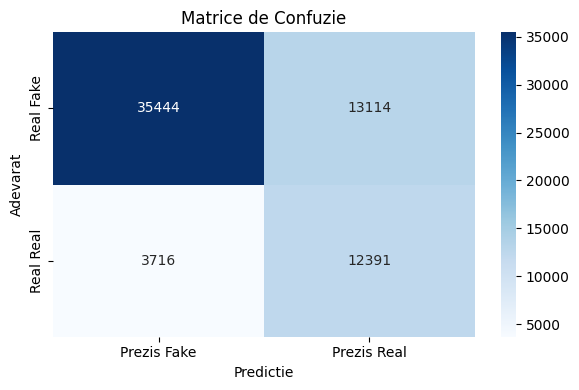

In [43]:
# trecem in modul de evaluare - dezactiveaza Dropout si fixeaza BatchNorm
# [[[[[[ model.eval() e perechea lui model.train()
#        daca uiti sa il apelezi, rezultatele pot fi diferite la fiecare run ]]]]]]
model.eval()

all_labels = []
all_preds  = []

# dezactivam calculul de gradiente - nu facem backprop, doar inferenta
# [[[[[[ torch.no_grad() reduce consumul de memorie si accelereaza inferenta
#        PyTorch nu mai tine minte lantul de operatii necesar pentru backward ]]]]]]
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # luam clasa cu scorul cel mai mare ca predictie finala
        _, preds = torch.max(outputs, 1)
        # [[[[[[ .cpu() muta tensorul de pe GPU in RAM inainte de .numpy()
        #        numpy nu poate accesa memoria GPU ]]]]]]
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# raportul complet cu precision, recall si f1 per clasa
# [[[[[[ precision = din ce am prezis ca e Fake, cat % chiar era Fake
#        recall    = din tot ce era Fake, cat % am gasit noi
#        f1-score  = media armonica intre cele doua - balanta intre ele ]]]]]]
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# matricea de confuzie ne arata exact tipul de greseli
# [[[[[[ False Positive: am prezis Fake dar era Real
#        False Negative: am prezis Real dar era Fake - mai periculos in context deepfake ]]]]]]
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prezis Fake', 'Prezis Real'],
            yticklabels=['Real Fake', 'Real Real'])
plt.title('Matrice de Confuzie')
plt.ylabel('Adevarat')
plt.xlabel('Predictie')
plt.tight_layout()
plt.show()

## 7. Inferenta pe Video Nou

In [ ]:
VIDEO_PATH = "video_test_true3.mp4"
MODEL_PATH = "model_deepfake_b0.pth"

# reconstituim exact aceeasi arhitectura din sectiunea 3 si incarcam greutatile salvate
# [[[[[[ daca arhitectura nu se potriveste cu ce s-a salvat, load_state_dict arunca eroare
#        de aia trebuie sa fie identica cu cea de la antrenament ]]]]]]
inf_model = models.efficientnet_b0(weights=None)
inf_model.classifier[1] = nn.Linear(inf_model.classifier[1].in_features, 2)
inf_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
inf_model = inf_model.to(device)
inf_model.eval()

# la inferenta nu mai avem augmentare - vrem predictii stabile si repetabile
inf_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# refolosim face_detector initializat la inceputul sectiunii 2

cap = cv2.VideoCapture(VIDEO_PATH)
votes_fake  = 0
votes_real  = 0
frame_count = 0
debug_saved = False

print(f"procesam: {VIDEO_PATH}")

# strategia de votare majoritara: fiecare cadru analziat da un vot
# verdictul final e clasa cu cele mai multe voturi - mai robust decat un singur frame
# [[[[[[ voting e o metoda de ensemble simpla
#        un singur frame poate fi nereprezenativ (ochi inchisi, blur etc.) ]]]]]]
with torch.no_grad():
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break

        frame_count += 1
        # analizam 1 cadru din 5 ca sa nu fie prea lent, 6fps -> ~1.2 analize/sec
        if frame_count % 5 != 0:
            continue

        face = crop_face(frame)
        if face is None:
            continue

        # salvam primul crop pentru debug - verificam vizual ca taietura e corecta
        if not debug_saved:
            cv2.imwrite("debug_crop.jpg", cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
            debug_saved = True

        # pregatim tensorul si il dam modelului
        # [[[[[[ unsqueeze(0) adauga o dimensiune de batch: (C,H,W) -> (1,C,H,W)
        #        reteaua se asteapta la batch-uri, chiar daca e o singura imagine ]]]]]]
        tensor = inf_transforms(Image.fromarray(face)).unsqueeze(0).to(device)
        out    = inf_model(tensor)

        # convertim logits in probabilitati cu softmax si luam predictia
        # [[[[[[ softmax transforma orice vector de numere in probabilitati (suma = 1.0) ]]]]]]
        probs = F.softmax(out, dim=1)[0]
        pred  = torch.argmax(probs).item()

        # afisam primele 30 de cadre ca sa vedem evolutia scorurilor
        if frame_count <= 30:
            print(f"cadru {frame_count}: fake={probs[0]*100:.1f}% real={probs[1]*100:.1f}%")

        if pred == 0:
            votes_fake += 1
        else:
            votes_real += 1

cap.release()

# calculam si afisam verdictul final pe baza voturilor acumulate
total = votes_fake + votes_real
if total == 0:
    print("nicio fata detectata in video")
else:
    pct_fake = votes_fake / total * 100
    pct_real = votes_real / total * 100
    print(f"\nRezultat final ({total} cadre analizate):")
    print(f"  FAKE: {pct_fake:.1f}%  |  REAL: {pct_real:.1f}%")
    verdict = "FAKE" if votes_fake > votes_real else "REAL"
    print(f"  => Videoclipul pare: {verdict}")